Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Loaded full results: n=32598.
Conditions: ['C1', 'C4', 'C5_L1', 'C5_L2'] | n per cell: 32 - 32


,condition,model_tier,n,EX,CI_low,CI_high,col_recall,col_precision
0,C1,MID,32,0.4688,0.3087,0.6355,0.9792,0.1080
3,C4,MID,32,0.4062,0.2552,0.5774,0.9494,0.1469
6,C5_L1,MID,32,0.3750,0.2293,0.5475,0.8714,0.1715
9,C5_L2,MID,32,0.3125,0.1795,0.4857,0.8852,0.2899
1,C1,STRONG,32,0.3438,0.2041,0.5169,0.9792,0.1080
4,C4,STRONG,32,0.3438,0.2041,0.5169,0.9494,0.1469
7,C5_L1,STRONG,32,0.4062,0.2552,0.5774,0.8714,0.1715
10,C5_L2,STRONG,32,0.3125,0.1795,0.4857,0.8852,0.2899
2,C1,WEAK,32,0.3438,0.2041,0.5169,0.9792,0.1080
5,C4,WEAK,32,0.3125,0.1795,0.4857,0.9494,0.1469


Saved table: 07_rq5_table.csv, 07_rq5_table.tex
Saved figure: 07_rq5_ex_by_condition.png, 07_rq5_ex_by_condition.pdf


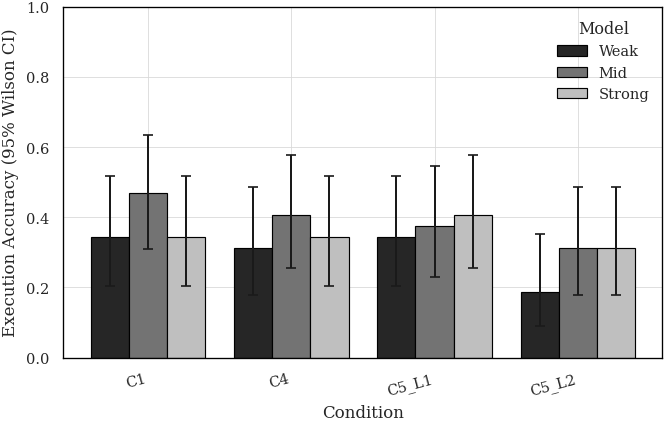

Saved figure: 07_rq5_recall_precision.png, 07_rq5_recall_precision.pdf


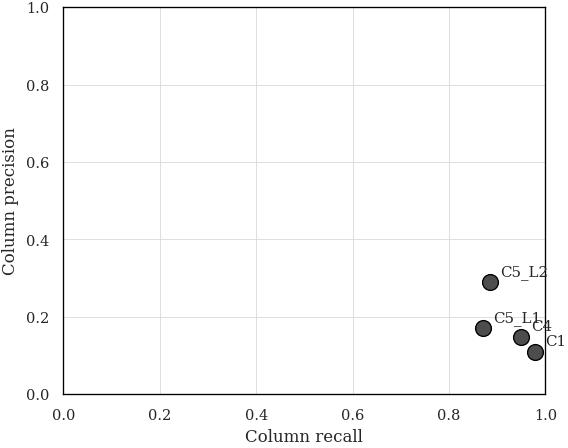

,databases,columns_total,columns_with_sample_values,total_sample_values_stored,raw_rows_stored,note
0,1,55,55,163,0,metadata + representative sample values only; ...


Saved table: 07_rq5_pii_audit.csv, 07_rq5_pii_audit.tex
Interpretation: the graph stores schema + a few representative sample values per column, never full rows or PII records. For a strict no-value policy, rebuild contexts with include_samples=False.


In [1]:
# ============================================================================
# 07_rq5_finance_domain.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# RQ5: Does metadata-only graphing help in a domain-glossary-heavy setting
#      (finance) while keeping PII non-movement? Uses D2_fin (BIRD financial
#      proxy). NOTE: D2_fin has only 32 questions here, so results are reported as
#      a small-sample pilot with wide uncertainty, not a definitive claim.
#
# Consumes : results/tables/generation_results.csv
# Produces : 07_rq5_ex_by_condition.{png,pdf}
#            07_rq5_recall_precision.{png,pdf}
#            07_rq5_table.{csv,tex}
#            07_rq5_pii_audit.{csv,tex}     (metadata-only / no-PII audit)
#
# Anonymity: no filesystem paths are printed.
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load configuration + results

# %%
%run 00_setup_and_config.ipynb


# %%
def load_results():
    full = TABLES_DIR / "generation_results.csv"
    if full.exists():
        df = pd.read_csv(full); print(f"Loaded full results: n={len(df)}.")
    else:
        raise FileNotFoundError("Run notebook 02 first.")
    return df

res = load_results()


# %% [markdown]
# ## Cell 2 - Scope to the finance proxy (D2_fin)
# Small sample -> we compute Wilson confidence intervals for EX and flag n.

# %%
rq5 = res[res["dataset"] == "D2_fin"].copy()
if not len(rq5):
    print("[note] D2_fin not present in results. Enable it in notebook 02 FULL_PLAN.")
print("Conditions:", sorted(rq5["condition"].unique()),
      "| n per cell:", rq5.groupby(["condition", "model_tier"])["qid"].count().min(),
      "-", rq5.groupby(["condition", "model_tier"])["qid"].count().max()
      if len(rq5) else "n/a")


# %% [markdown]
# ## Cell 3 - EX table with Wilson 95% CI (small-sample honest reporting)

# %%
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (max(0, center - half), min(1, center + half))

rows = []
for (cond, mt), g in rq5.dropna(subset=["exec_match"]).groupby(["condition", "model_tier"]):
    n = len(g); k = int(g["exec_match"].sum())
    lo, hi = wilson_ci(k, n)
    rows.append({"condition": cond, "model_tier": mt, "n": n,
                 "EX": round(k / n, 4) if n else np.nan,
                 "CI_low": round(lo, 4), "CI_high": round(hi, 4),
                 "col_recall": round(g["col_recall_strict"].mean(), 4),
                 "col_precision": round(g["col_precision_strict"].mean(), 4)})
rq5_table = pd.DataFrame(rows).sort_values(["model_tier", "condition"])
display(rq5_table)
save_table(rq5_table, "07_rq5_table")


# %% [markdown]
# ## Cell 4 - Figure: EX by condition with CI error bars (per model)
# Wide CIs are expected and honest at n=32; the figure shows overlap explicitly.

# %%
def plot_rq5_ex(df):
    d = df.dropna(subset=["exec_match"])
    if not len(d):
        print("No D2_fin EX rows."); return
    conds = sorted(d["condition"].unique(),
                   key=lambda c: (len(c), c))
    tiers = [t for t in MODEL_TIER_ORDER if t in d["model_tier"].unique()]
    fig, ax = plt.subplots(figsize=(5.8, 3.8))
    x = np.arange(len(conds)); w = 0.8 / max(1, len(tiers))
    for i, t in enumerate(tiers):
        means, los, his = [], [], []
        for c in conds:
            g = d[(d["condition"] == c) & (d["model_tier"] == t)]
            n = len(g); k = int(g["exec_match"].sum())
            m = k / n if n else np.nan
            lo, hi = wilson_ci(k, n)
            means.append(m); los.append(m - lo if n else 0); his.append(hi - m if n else 0)
        ax.bar(x + i * w, means, width=w, color=gray_palette(len(tiers))[i],
               edgecolor="black", linewidth=0.7,
               yerr=[los, his], capsize=3, label=MODEL_TIER_LABELS.get(t, t))
    ax.set_xticks(x + w * (len(tiers) - 1) / 2)
    ax.set_xticklabels(conds, rotation=15, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Execution Accuracy (95% Wilson CI)")
    ax.legend(title="Model")
    save_figure(fig, "07_rq5_ex_by_condition")
    plt.show()

plot_rq5_ex(rq5)


# %% [markdown]
# ## Cell 5 - Figure: recall vs precision across conditions (glossary effect)
# In a glossary-heavy domain, pruning still trades recall for precision; this
# shows whether any condition holds recall while gaining precision.

# %%
def plot_rq5_recall_precision(df):
    agg = (df.groupby("condition")
             .agg(recall=("col_recall_strict", "mean"),
                  precision=("col_precision_strict", "mean")).reset_index())
    if not len(agg):
        print("No rows."); return
    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    for _, r in agg.iterrows():
        ax.scatter(r["recall"], r["precision"], s=90, color="0.3",
                   edgecolor="black", linewidth=0.8, zorder=3)
        ax.annotate(r["condition"], (r["recall"], r["precision"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax.set_xlabel("Column recall")
    ax.set_ylabel("Column precision")
    ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.0)
    save_figure(fig, "07_rq5_recall_precision")
    plt.show()

plot_rq5_recall_precision(rq5)


# %% [markdown]
# ## Cell 6 - PII non-movement audit (compliance claim, auditable)
# Verifies that the semantic graph carries METADATA ONLY: it scans the built
# D2_fin schema/context artifacts for any raw row values. Sample values in the
# schema are representative cell values by design; this audit reports how many
# and lets you decide policy. (For a strict no-value policy, rebuild contexts
# with include_samples=False.)

# %%
def pii_audit_d2fin():
    # Count sample values embedded in the D2_fin schema.json (metadata store).
    spath = DATA_DIR / "D2_fin" / "schema.json"
    if not spath.exists():
        print("D2_fin schema.json not found."); return None
    schema = json.loads(spath.read_text(encoding="utf-8"))
    n_cols, n_with_samples, n_sample_values = 0, 0, 0
    for db in schema:
        for t, tinfo in db["tables"].items():
            for c, cinfo in tinfo["columns"].items():
                n_cols += 1
                sv = cinfo.get("sample_values", [])
                if sv:
                    n_with_samples += 1
                    n_sample_values += len(sv)
    audit = pd.DataFrame([{
        "databases": len(schema),
        "columns_total": n_cols,
        "columns_with_sample_values": n_with_samples,
        "total_sample_values_stored": n_sample_values,
        "raw_rows_stored": 0,     # the graph never stores full rows / PII records
        "note": "metadata + representative sample values only; no full rows/PII",
    }])
    display(audit)
    save_table(audit, "07_rq5_pii_audit")
    print("Interpretation: the graph stores schema + a few representative sample "
          "values per column, never full rows or PII records. For a strict "
          "no-value policy, rebuild contexts with include_samples=False.")
    return audit

_ = pii_audit_d2fin()